In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("income_evaluation.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print("İnformations: ")
df.info()
print("İsnull Values: ")
df.isnull().sum()

Shape:  (32561, 15)
Columns:  Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')
İnformations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  in

age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

In [3]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


In [4]:
categorical = [i for i in df.columns if df[i].dtype == "O"]
numerical = [i for i in df.columns if df[i].dtype != "O"]
print(categorical)
print(numerical)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [5]:
df[categorical].head()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [6]:
for i in categorical:
    print(df[i].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

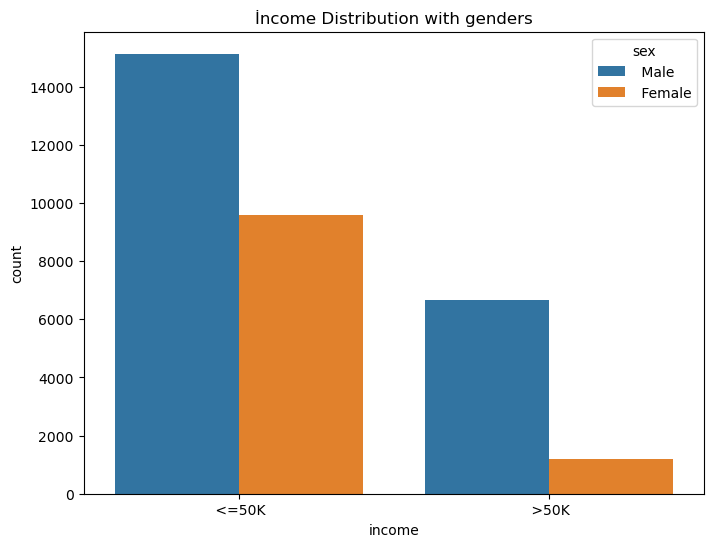

In [7]:
plt.figure(figsize=(8,6))
sns.countplot(x="income", hue="sex", data=df)
plt.title("İncome Distribution with genders")
plt.show()

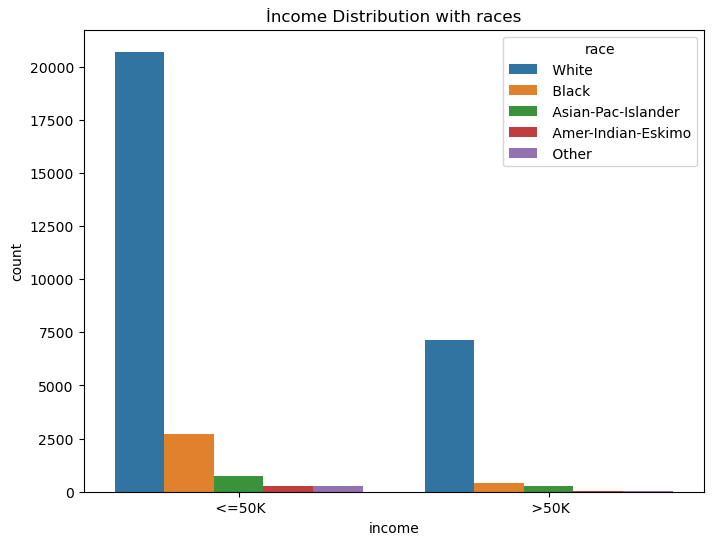

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(x="income", hue="race", data=df)
plt.title("İncome Distribution with races")
plt.show()

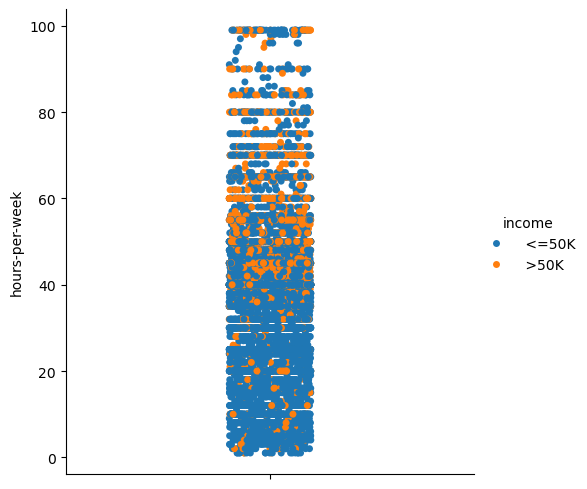

In [9]:
sns.catplot(y="hours-per-week", hue="income", data=df)
plt.show()

In [10]:
print(df[df["hours-per-week"] > 40]["income"].value_counts())
print(df[df["hours-per-week"] <= 40]["income"].value_counts())

income
<=50K    5725
>50K     3856
Name: count, dtype: int64
income
<=50K    18995
>50K      3985
Name: count, dtype: int64


In [11]:
3856 / (3856 + 5725)

0.4024632084333577

In [12]:
3985 / (3985 + 18995)

0.17341166231505656

In [13]:
categorical

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'income']

In [14]:
for i in categorical:
    df[i] = df[i].str.strip()

for j in categorical:
    print(f"{j} unique values: ")
    print(df[j].unique())

workclass unique values: 
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education unique values: 
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
marital-status unique values: 
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation unique values: 
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
relationship unique values: 
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race unique values: 
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex unique values: 
['Male' 'Female']
native-coun

In [15]:
def solve():
    cols = []
    for i in categorical:
        if "?" in df[i].unique():
            cols.append(i)
    return cols

In [16]:
columns = solve()
df[columns] = df[columns].replace("?", np.nan)

In [17]:
for k in columns:
    print(df[k].unique())

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
['United-States' 'Cuba' 'Jamaica' 'India' nan 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']


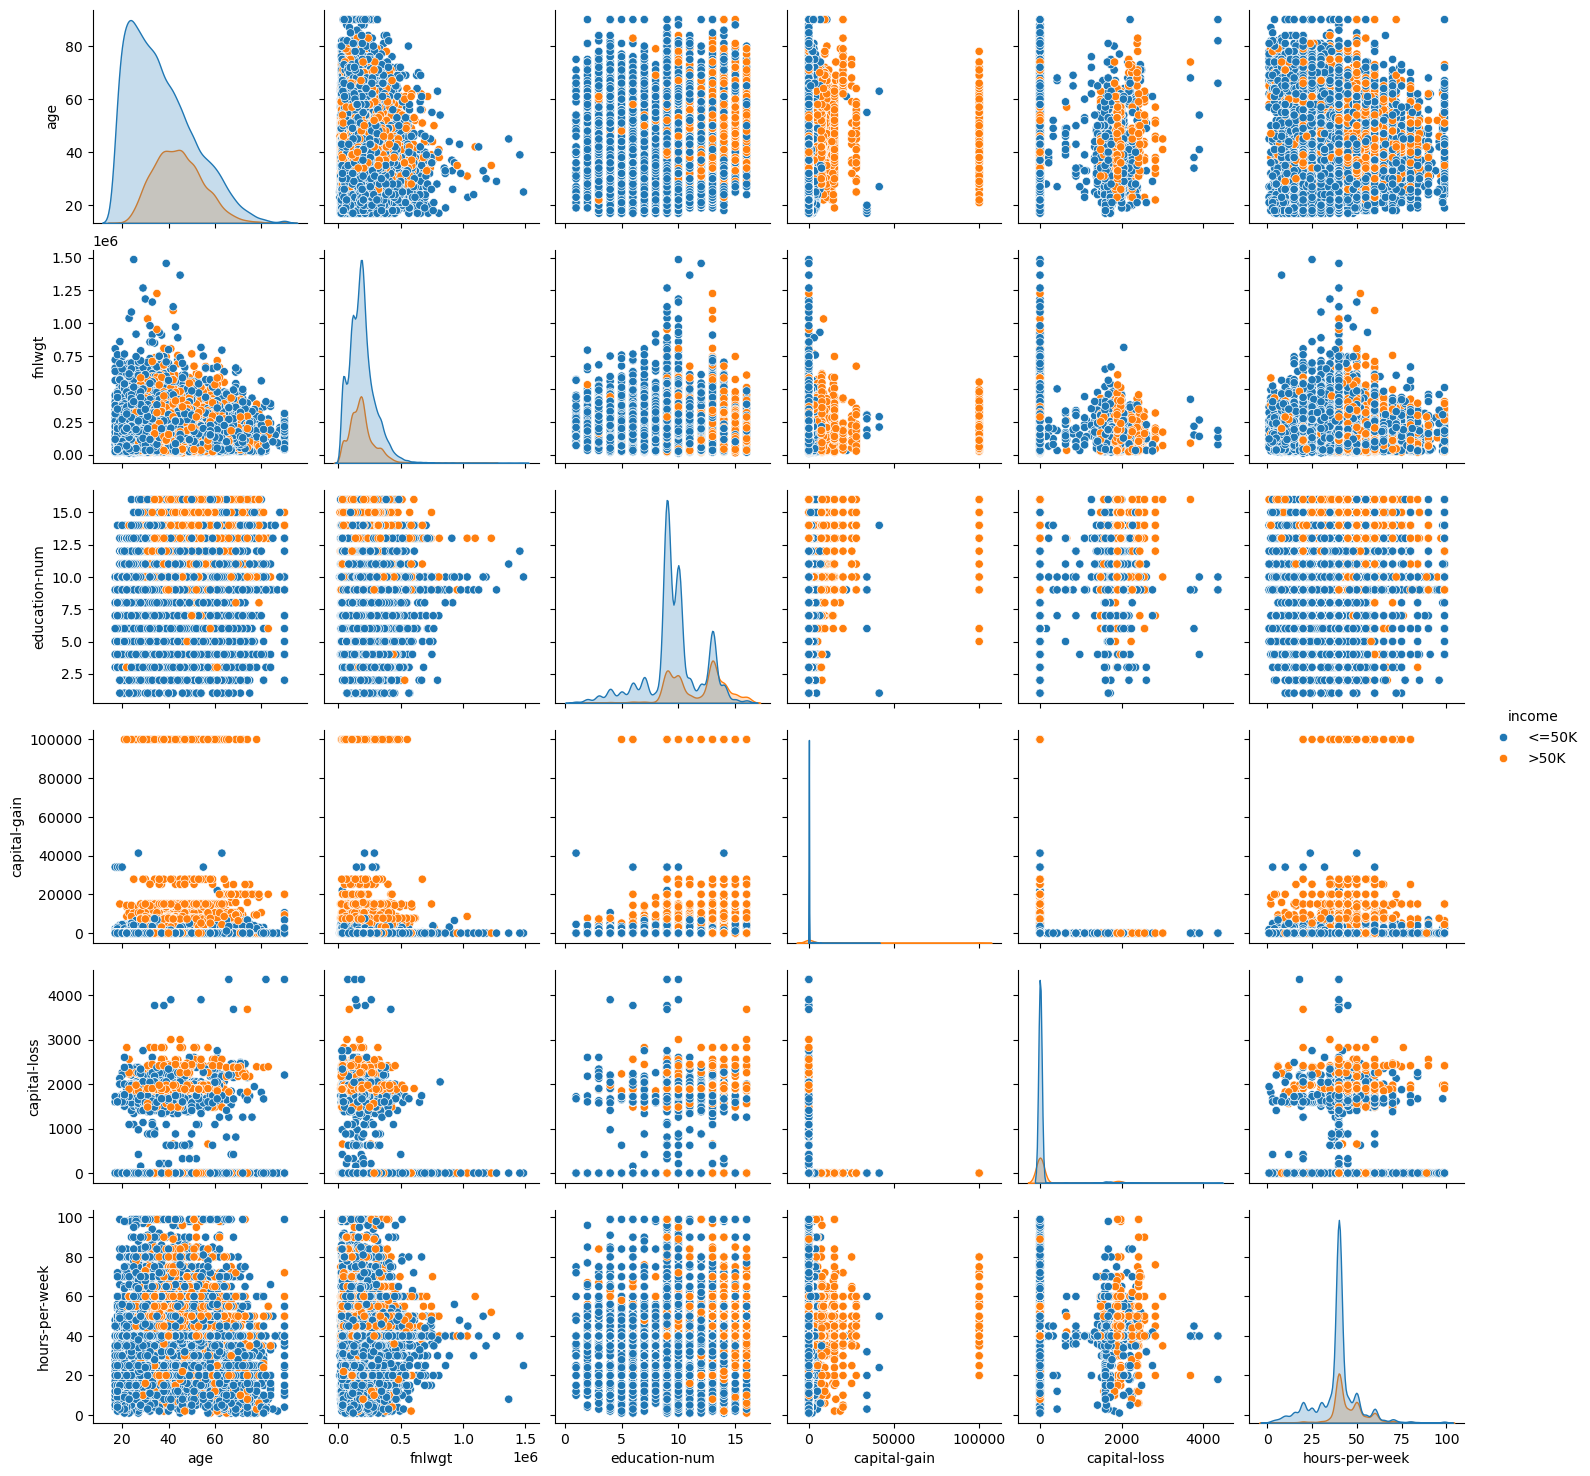

In [18]:
sns.pairplot(df, hue="income")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
X = df.drop("income", axis=1)
y = df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [20]:
categorical = [i for i in X_train.columns if X_train[i].dtype == "O"]
numerical = [i for i in X_train.columns if X_train[i].dtype != "O"]

In [21]:
X_train.isnull().sum()

age                  0
workclass         1262
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1265
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     392
dtype: int64

In [22]:
X_test.isnull().sum()

age                 0
workclass         574
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        578
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    191
dtype: int64

In [23]:
for k in ["workclass", "occupation", "native-country"]:
    X_train[k] = X_train[k].fillna(X_train[k].mode()[0])
    X_test[k] = X_test[k].fillna(X_train[k].mode()[0])

In [24]:
X_train.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [25]:
X_test.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [26]:
y_train_binary = y_train.map({"<=50K": 0, ">50K":1})

In [27]:
import warnings
warnings.filterwarnings("ignore")

In [28]:
target_means = X_train.join(y_train_binary).groupby("native-country")["income"].mean()
X_train["native_encoded"] = X_train["native-country"].map(target_means)
X_test["native_encoded"] = X_test["native-country"].map(target_means)
X_test["native_encoded"].fillna(y_train_binary.mean(), inplace=True)

In [29]:
display(X_train.head())
X_train = X_train.drop("native-country", axis=1)
X_test = X_test.drop("native-country", axis=1)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,native_encoded
32174,44,Self-emp-not-inc,157217,Bachelors,13,Never-married,Sales,Not-in-family,White,Male,0,0,42,United-States,0.247311
2680,26,Local-gov,336969,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,28,El-Salvador,0.129032
10874,53,Private,233369,Some-college,10,Widowed,Exec-managerial,Unmarried,White,Female,0,0,40,United-States,0.247311
25028,30,Private,348618,9th,5,Married-civ-spouse,Craft-repair,Husband,Other,Male,0,0,40,Mexico,0.062907
25881,50,Self-emp-inc,140516,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,0.247311


In [30]:
one_hot_cateogires = [
     'workclass',
     'education',
     'marital-status',
     'occupation',
     'relationship',
     'race',
     'sex',
]

In [31]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_cateogires)],
        remainder="passthrough"
)
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

In [32]:
X_train_enc

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.20000000e+01, 2.47311312e-01],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 2.80000000e+01, 1.29032258e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.47311312e-01],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 5.00000000e+01, 2.47311312e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.57900000e+03, 4.00000000e+01, 2.47311312e-01],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 4.00000000e+01, 2.47311312e-01]],
      shape=(22792, 65))

In [33]:
columns = encoder.get_feature_names_out()
print(columns)

['cat__workclass_Federal-gov' 'cat__workclass_Local-gov'
 'cat__workclass_Never-worked' 'cat__workclass_Private'
 'cat__workclass_Self-emp-inc' 'cat__workclass_Self-emp-not-inc'
 'cat__workclass_State-gov' 'cat__workclass_Without-pay'
 'cat__education_10th' 'cat__education_11th' 'cat__education_12th'
 'cat__education_1st-4th' 'cat__education_5th-6th'
 'cat__education_7th-8th' 'cat__education_9th' 'cat__education_Assoc-acdm'
 'cat__education_Assoc-voc' 'cat__education_Bachelors'
 'cat__education_Doctorate' 'cat__education_HS-grad'
 'cat__education_Masters' 'cat__education_Preschool'
 'cat__education_Prof-school' 'cat__education_Some-college'
 'cat__marital-status_Divorced' 'cat__marital-status_Married-AF-spouse'
 'cat__marital-status_Married-civ-spouse'
 'cat__marital-status_Married-spouse-absent'
 'cat__marital-status_Never-married' 'cat__marital-status_Separated'
 'cat__marital-status_Widowed' 'cat__occupation_Adm-clerical'
 'cat__occupation_Armed-Forces' 'cat__occupation_Craft-repair

In [34]:
X_train_enc = pd.DataFrame(X_train_enc, columns=columns, index=X_train.index)
X_test_enc = pd.DataFrame(X_test_enc, columns=columns, index=X_test.index)

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), index=X_train_enc.index, columns=columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), index=X_test_enc.index, columns=columns)

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train_scaled, y_train)
y_pred = rfc.predict(X_test_scaled)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred))
print("Classification Report: ", "\n", classification_report(y_test, y_pred))

Accuracy Score:  0.8626266762206981
Confusion Matrix:  
 [[6926  518]
 [ 824 1501]]
Classification Report:  
               precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7444
        >50K       0.74      0.65      0.69      2325

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [65]:
feature_scores = pd.Series(rfc.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
cols_to_drop = feature_scores.tail(10).index

In [67]:
X_train_scaled1 = X_train_scaled.drop(cols_to_drop, axis=1)
X_test_scaled1 = X_test_scaled.drop(cols_to_drop, axis=1)

In [69]:
rfc1 = RandomForestClassifier(n_estimators=100, random_state=15)
rfc1.fit(X_train_scaled1, y_train)
y_pred1 = rfc1.predict(X_test_scaled1)
print("Accuracy Score: ", accuracy_score(y_test, y_pred1))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred1))
print("Classification Report: ", "\n", classification_report(y_test, y_pred1))

Accuracy Score:  0.8642645101852799
Confusion Matrix:  
 [[6937  507]
 [ 819 1506]]
Classification Report:  
               precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7444
        >50K       0.75      0.65      0.69      2325

    accuracy                           0.86      9769
   macro avg       0.82      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [74]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "max_features": ["sqrt", "log2", 5, 6, 7, 8],
    "min_samples_split": [2, 5, 10, 20]
}
cv = StratifiedKFold()
rscv = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=params, n_jobs=-1, scoring="accuracy", cv=cv)
rscv.fit(X_train_scaled, y_train)
y_pred2 = rscv.predict(X_test_scaled)
print("Accuracy Score: ", accuracy_score(y_test, y_pred2))
print("Confusion Matrix: ", "\n", confusion_matrix(y_test, y_pred2))
print("Classification Report: ", "\n", classification_report(y_test, y_pred2))

Accuracy Score:  0.8717371276486846
Confusion Matrix:  
 [[6998  446]
 [ 807 1518]]
Classification Report:  
               precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      7444
        >50K       0.77      0.65      0.71      2325

    accuracy                           0.87      9769
   macro avg       0.83      0.80      0.81      9769
weighted avg       0.87      0.87      0.87      9769



In [84]:
y_train = y_train.map({"<=50K":0, ">50K":1})
y_test = y_test.map({"<=50K":0, ">50K":1})

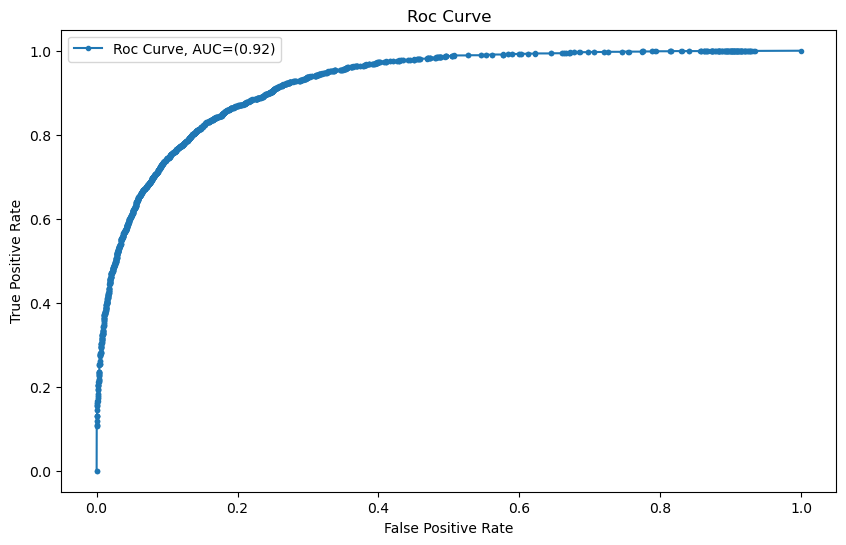

In [85]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = rscv.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(10,6))
plt.plot(fpr, tpr, marker=".", label=f"Roc Curve, AUC=({roc_auc_score(y_test, y_prob):.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc Curve")
plt.legend()
plt.show()